COSC 301 Project
Group 4
Instacart Market Basket Analysis

**Importing Files**

The way to run this program is by running bash scripts/get_data.sh in terminal 

In [11]:
import pandas as pd               # for data manipulation
import matplotlib.pyplot as plt   # for plotting 
import seaborn as sns             # for statistical graph
import sqlite3                    # for connecting to the database
import os                         # for file path operations
from sklearn.metrics.pairwise import cosine_similarity
from scipy.sparse import csr_matrix
import numpy as np

In [12]:
DB_PATH = "instacart.db"

# ✅ check first
db_exists = os.path.exists(DB_PATH)

# then connect
conn = sqlite3.connect(DB_PATH)

if not db_exists:
    print("Database not found. Creating from CSVs...")

    # Load from CSV (ONLY first time)
    orders = pd.read_csv('../raw_data/orders.csv')
    products = pd.read_csv('../raw_data/products.csv')
    order_products_prior = pd.read_csv('../raw_data/order_products__prior.csv')
    aisles = pd.read_csv('../raw_data/aisles.csv')
    order_products_train = pd.read_csv('../raw_data/order_products__train.csv')

    # Save to SQL
    orders.to_sql("orders", conn, index=False)
    products.to_sql("products", conn, index=False)
    order_products_prior.to_sql("order_products_prior", conn, index=False)
    aisles.to_sql("aisles", conn, index=False)
    order_products_train.to_sql("order_products_train", conn, index=False)

    print("Database created successfully!")

else:
    print("Database found. Loading from SQL...")

    orders = pd.read_sql_query("SELECT * FROM orders", conn)
    products = pd.read_sql_query("SELECT * FROM products", conn)
    order_products_prior = pd.read_sql_query("SELECT * FROM order_products_prior", conn)
    aisles = pd.read_sql_query("SELECT * FROM aisles", conn)
    order_products_train = pd.read_sql_query("SELECT * FROM order_products_train", conn)

Database found. Loading from SQL...


In [13]:
orders.head()

,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1,prior,1,2,8,NaN
1,2398795,1,prior,2,3,7,15.0
2,473747,1,prior,3,3,12,21.0
3,2254736,1,prior,4,4,7,29.0
4,431534,1,prior,5,4,15,28.0


## Research Question 1

How accurately will we recommend the top 5 products a user is most likely to purchase in their next order based on their previous orders (using the order_product_prior csv file)?

Steps taken:

Step 1: Create dataframe with all orders of each user along with details of the products in the order.

Step 2: From per-user, per-product history, calculate the number of times a user bought a product, last order they bought it in, and the reorder rate for that product for that user.

Step 3: Implement the 2 recommendation algorithms: the first one recommends top 5 products based on frequency of ordering the product that the user has order in all of their order. The second one uses the popular products in each aisle and the popular aisles that the user orders from and recommends those top 5 items.

Step 4: Run the 2 recommendation algorithms. Compute metrics by comparing the recommended 5 products with the training set of products for the users.

In [14]:
# Join prior order-products with orders to get user_id + order_number
op_prior = order_products_prior.merge(
    orders[['order_id', 'user_id', 'order_number']],
    on='order_id',
    how='left'
)

# add product meta (name/aisle/department)
prod_meta = products[['product_id', 'product_name', 'aisle_id', 'department_id']].copy()
op_prior = op_prior.merge(prod_meta, on='product_id', how='left')

# now we have a dataframe with info order, products in the order, and user who made the order.
op_prior.head()


,order_id,product_id,add_to_cart_order,reordered,user_id,order_number,product_name,aisle_id,department_id
0,2,33120,1,1,202279,3,Organic Egg Whites,86,16
1,2,28985,2,1,202279,3,Michigan Organic Kale,83,4
2,2,9327,3,0,202279,3,Garlic Powder,104,13
3,2,45918,4,1,202279,3,Coconut Butter,19,13
4,2,30035,5,0,202279,3,Natural Sweetener,17,13


### Frequency-based Recommendation Algorithm

Here, we create the users' ordered products statistics and then the 1st recommendation algorithm which recommends the top 5 most frequently ordered products for the specified user.

In [15]:
# Per-user, per-product stats from PRIOR history
# calculating the numbers of times a user bought a product, the last order number they bought it in, 
# and the reorder rate for that product for that user.
user_prod_stats = (
    op_prior.groupby(['user_id', 'product_id'], as_index=False)
    .agg(
        times_bought=('order_id', 'count'),
        last_order_number=('order_number', 'max'),
        reorder_rate=('reordered', 'mean')
    )
)

# merge names for readability
user_prod_stats = user_prod_stats.merge(prod_meta, on='product_id', how='left')

# recommendation function based on frequency of a product being ordered; accepts user id and number of recommendations to make
def recommend_top5_frequency(user_id: int, n: int = 5):
    """
    - prefer items bought often
    - prefer items bought recently
    - prefer items with high reorder_rate
    """
    
    df = user_prod_stats[user_prod_stats['user_id'] == user_id].copy()
    if df.empty:
        return pd.DataFrame(columns=['product_id','product_name','times_bought','reorder_rate','last_order_number'])

    df = df.sort_values(
        by=['times_bought', 'last_order_number', 'reorder_rate'],
        ascending=[False, False, False]
    )
    return df[['user_id','product_id','product_name','times_bought','reorder_rate','last_order_number']].head(n)

# try
recommend_top5_frequency(1)

,user_id,product_id,product_name,times_bought,reorder_rate,last_order_number
0,1,196,Soda,10,0.900000,10
3,1,12427,Original Beef Jerky,10,0.900000,10
1,1,10258,Pistachios,9,0.888889,10
8,1,25133,Organic String Cheese,8,0.875000,10
4,1,13032,Cinnamon Toast Crunch,3,0.666667,10


### Top aisles based recommendation algorithm

Now we calculate the global product popularity, users' preferred aisles, and the aisles' popular products. After this we create the 2nd recommendation algorithm which recommended the top 5 products a user orders from the aisles they most popularly order from.

In [16]:
# Global popularity + reorder rate per product (from op_prior)
# aggregate variables are global_times and global_reorder_rate
global_prod_stats = (
    op_prior.groupby('product_id', as_index=False)
    .agg(
        global_times=('order_id', 'count'),
        global_reorder_rate=('reordered', 'mean')
    )
).merge(prod_meta, on='product_id', how='left')

# User aisle preferences
#aisle_count is the number of a times the aisle was mentioned in a prior order for a user.
user_aisle_pref = (
    op_prior.groupby(['user_id', 'aisle_id'], as_index=False)
    .agg(aisle_count=('order_id', 'count'))
)

# Popular products within each aisle
#this is different from user_aisle_pref because it is number of times a product in an aisle was ordered in general and not specific to a user.
aisle_prod_pop = (
    op_prior.groupby(['aisle_id', 'product_id'], as_index=False)
    .agg(aisle_prod_count=('order_id', 'count'))
).merge(global_prod_stats, on=['product_id','aisle_id'], how='left')


def recommend_top5_aisle(user_id: int, n: int = 5, top_aisles: int = 3):
    """
    Content-based recommender:
    1) find user's top aisles
    2) recommend popular products from those aisles
       (rank by aisle popularity + global reorder rate)
    """
    
    # top aisles for the specified user
    top_aisles_for_user = (
        user_aisle_pref[user_aisle_pref['user_id'] == user_id]
        .sort_values('aisle_count', ascending=False)
        .head(top_aisles)['aisle_id']
        .tolist()
    )
        
    if not top_aisles_for_user:
        return pd.DataFrame(columns=['product_id','product_name','aisle_id','aisle_prod_count','global_reorder_rate'])

    popular_prod_AND_in_top_aisle_for_user = aisle_prod_pop[aisle_prod_pop['aisle_id'].isin(top_aisles_for_user)].copy()
    
    # recommend products which could be new or a reorder for the user.
    # sorting products to recommend by aisle
    popular_prod_AND_in_top_aisle_for_user = popular_prod_AND_in_top_aisle_for_user.sort_values(
        by=['aisle_prod_count', 'global_reorder_rate', 'global_times'],
        ascending=[False, False, False]
    )

    return popular_prod_AND_in_top_aisle_for_user[['product_id','product_name','aisle_id','aisle_prod_count','global_reorder_rate']].head(n)

# try
recommend_top5_aisle(1)

,product_id,product_name,aisle_id,aisle_prod_count,global_reorder_rate
26966,196,Soda,77,35791,0.776480
27077,10957,Fridge Pack Cola,77,18269,0.715255
8257,3599,Baked Aged White Cheddar Rice and Corn Puffs,23,13691,0.643635
8337,15902,100 Calorie Per Bag Popcorn,23,12822,0.678209
44079,35140,Organic Whole Cashews,117,12816,0.605025


### Truth set and Evaluation of recommendation algorithms

Below we create the truth set which is based on the train dataset. After that, we evaluate the 2 recommendation algorithms using precision and recall metrics.

In [17]:
# Build user -> set of products in their TRAIN order (the "next order" we are trying to predict)
op_train = order_products_train.merge(
    orders[['order_id', 'user_id']],
    on='order_id',
    how='left'
)

truth = (
    op_train.groupby('user_id')['product_id']
    .apply(lambda s: set(s.values))
    .to_dict()
)

import random

def precision_at_k(recs, truth_set, k=5):
    recs = list(recs)[:k]
    if not recs:
        return 0.0
    hits = len(set(recs) & truth_set)
    return hits / k

def recall_at_k(recs, truth_set, k=5):
    recs = list(recs)[:k]
    if not truth_set:
        return 0.0
    hits = len(set(recs) & truth_set)
    return hits / len(truth_set)

def eval_recommender(user_ids, recommender_fn, k=5):
    ps, rs = [], []
    for uid in user_ids:
        if uid not in truth:
            continue
        rec_df = recommender_fn(uid, n=k)
        recs = rec_df['product_id'].tolist() if 'product_id' in rec_df else []
        ps.append(precision_at_k(recs, truth[uid], k))
        rs.append(recall_at_k(recs, truth[uid], k))
    return (sum(ps)/len(ps), sum(rs)/len(rs)) if ps else (0.0, 0.0)

# sample users for speed
all_users = list(truth.keys())
sample_users = random.sample(all_users, k=min(2000, len(all_users)))

p1, r1 = eval_recommender(sample_users, recommend_top5_frequency, k=5)
p2, r2 = eval_recommender(sample_users, recommend_top5_aisle, k=5)

print("Baseline Frequency  P@5:", round(p1,4), " R@5:", round(r1,4))
print("Aisle Content-Based P@5:", round(p2,4), " R@5:", round(r2,4))

Baseline Frequency  P@5: 0.3548  R@5: 0.2388
Aisle Content-Based P@5: 0.0934  R@5: 0.0534


Based on the above metrics printed, the performance is much better for the frequency based method rather than the aisle popularity method of recommendation.

Now let us see some other algorithms and how the performance is when using them to make the recommendations.

### Item based collaborative filtering

The logic in this method is that if a user buys an item, another item similar to this one would also be bought.

In [18]:
# Taking the top 5000 popularly ordered products to for the CF model to run well on my machine.
top_products = op_prior.groupby('product_id')['order_id'].count().nlargest(5000).index

# Filtering the prior orders which have a top product and also a user in the sample_users list
op_prior_filtered = op_prior[
    op_prior['product_id'].isin(top_products) &
    op_prior['user_id'].isin(sample_users)
]

# Build user-product matrix which is a pivot table with the count of orders for each user-product pair.
user_product_matrix = op_prior_filtered.pivot_table(
    index='user_id',
    columns='product_id',
    values='order_id',
    aggfunc='count',
    fill_value=0
)

# Convert to sparse matrix for efficiency
sparse_matrix = csr_matrix(user_product_matrix.values)

Here we are calculating the item similarity between all the items in the sparse imatrix

In [19]:
# Cosine similarity between products. taking the transpose so that products are in the rows
item_similarity = cosine_similarity(sparse_matrix.T)

# Wrapping in a DataFrame for easy lookup
item_sim_df = pd.DataFrame(
    item_similarity,
    index=user_product_matrix.columns,
    columns=user_product_matrix.columns
)

Below is the recommendation algorithm based on Item-based Collaborative filtering

In [20]:
def recommend_item_based_cf(user_id, n=5, n_similar=10):
    if user_id not in user_product_matrix.index:
        return pd.DataFrame(columns=['product_id'])
    
    # products this user has already bought before.
    user_purchases = user_product_matrix.loc[user_id]
    bought_products = user_purchases[user_purchases > 0].index.tolist()
    
    if not bought_products:
        return pd.DataFrame(columns=['product_id'])
    
    # Accumulate similarity scores across all bought products
    scores = pd.Series(dtype=float)
    for product in bought_products:
        if product not in item_sim_df.index:
            continue
        # get top N similar products to the current one
        similar = item_sim_df[product].drop(index=bought_products, errors='ignore')
        similar = similar.nlargest(n_similar)
        scores = scores.add(similar, fill_value=0)
    
    # sort by the score and take top n products to recommend
    top_products = (
        scores.sort_values(ascending=False)
        .head(n)
        .reset_index()
        .rename(columns={'index': 'product_id', 0: 'score'})
    )
    return top_products[['product_id']]

Now, we will evaluate the recommendation algorithm against the truth set.

In [21]:
# evaluate the CF recommendation algorithm on users present in the user-product matrix and in the truth set
cf_users = set(user_product_matrix.index)
sample_users_cf = [u for u in sample_users if u in cf_users and u in truth]

print(f"Eligible users for CF eval: {len(sample_users_cf)}")

p3, r3 = eval_recommender(sample_users_cf, recommend_item_based_cf, k=5)
print("Item-Based CF P@5:", round(p3, 4), " R@5:", round(r3, 4))

Eligible users for CF eval: 1997
Item-Based CF P@5: 0.01  R@5: 0.0051


## Research Question 2

**How does recommendation performance change with user history size?**

This question explores whether users with more order history receive better recommendations. Intuitively, a frequency-based recommender should perform better for users with many prior orders because it has more data to learn their preferences. Users with little history (or cold start users) may get worse recommendations since the model has less signal to work with.

**User groupings:**
- **Few prior orders (< 5)**: Users with fewer than 5 prior orders—includes near cold-start users
- **Moderate history (5 to 20 prior orders)**: Users with enough history to establish some patterns
- **Heavy users (> 20 prior orders)**: Users with extensive order history

**Approach:** We use the same frequency-based recommender from Research Question 1 and evaluate precision@5, recall@5, and hit rate@5 separately for each history group.

In [22]:
# Compute each user's history size: number of prior orders (before the held-out train order)
# op_prior has all prior order-product pairs; we count distinct order_ids per user
user_prior_order_count = op_prior.groupby('user_id')['order_id'].nunique().reset_index()
user_prior_order_count.columns = ['user_id', 'prior_order_count']

# Assign users to history groups
def assign_history_group(count):
    if count < 5:
        return '< 5 prior orders'
    elif count <= 20:
        return '5 to 20 prior orders'
    else:
        return '> 20 prior orders'

user_prior_order_count['history_group'] = user_prior_order_count['prior_order_count'].apply(assign_history_group)

# Keep only users who have a train order (ground truth) for evaluation
user_history = user_prior_order_count[user_prior_order_count['user_id'].isin(truth.keys())].copy()

# Cold start: users in truth (train) but not in prior orders - excluded from RQ2
cold_start = set(truth.keys()) - set(user_prior_order_count['user_id'])
if cold_start:
    print(f"Cold start users (in train but no prior orders): {len(cold_start)} — excluded from RQ2")
print()
print("User distribution by history group:")
print(user_history['history_group'].value_counts().sort_index())
print()
print("Prior order count stats:")
print(user_history['prior_order_count'].describe())


User distribution by history group:
history_group
5 to 20 prior orders    72975
< 5 prior orders        27739
> 20 prior orders       30495
Name: count, dtype: int64

Prior order count stats:
count    131209.000000
mean         15.603937
std          16.661077
min           3.000000
25%           5.000000
50%           9.000000
75%          19.000000
max          99.000000
Name: prior_order_count, dtype: float64


### Performance by history group

We evaluate the same frequency-based recommender on each group. Metrics:
- **Precision@5**: Of the 5 recommendations, what fraction are in the user's actual next order?
- **Recall@5**: Of the products in the user's actual order, what fraction did we recommend?
- **Hit rate@5**: What fraction of users got at least one correct recommendation?

In [23]:
# Evaluate recommender per history group using same method as Research Question 1
# Add hit rate at k: fraction of users with at least one correct recommendation
import time

def hit_rate_at_k(recs, truth_set, k=5):
    recs = list(recs)[:k]
    if not recs:
        return 0.0
    hits = len(set(recs) & truth_set)
    return 1.0 if hits > 0 else 0.0

def eval_recommender_rq2(user_ids, recommender_fn, k=5):
    """Returns (avg_precision, avg_recall, avg_hit_rate) for the given user list."""
    ps, rs, hrs = [], [], []
    start_time = time.time()
    total_users = len(user_ids)
    for i, uid in enumerate(user_ids, 1):
        if uid not in truth:
            continue
        rec_df = recommender_fn(uid, n=k)
        recs = rec_df['product_id'].tolist() if 'product_id' in rec_df and len(rec_df) > 0 else []
        ps.append(precision_at_k(recs, truth[uid], k))
        rs.append(recall_at_k(recs, truth[uid], k))
        hrs.append(hit_rate_at_k(recs, truth[uid], k))
        if i % 50 == 0:
            elapsed = time.time() - start_time
            avg_time_per_user = elapsed / i
            remaining = total_users - i
            eta = avg_time_per_user * remaining
            print(f"[Progress] {i}/{total_users} users processed "
                  f"({(i/total_users)*100:.2f}%) | "
                  f"Elapsed: {elapsed:.2f}s | "
                  f"ETA: {eta:.2f}s")
    total_time = time.time() - start_time
    print(f"[Done] Processed {total_users} users in {total_time:.2f} seconds")
    n = len(ps)
    if n == 0:
        return 0.0, 0.0, 0.0
    return sum(ps)/n, sum(rs)/n, sum(hrs)/n

# Evaluate each history group with recommend_top5_frequency (same as RQ1)
results_rq2 = []
group_order = ['< 5 prior orders', '5 to 20 prior orders', '> 20 prior orders']
for grp in group_order:
    users_in_group = user_history[user_history['history_group'] == grp]['user_id'].tolist()
    if not users_in_group:
        continue
    print(f"\nEvaluating group: {grp} | Users: {len(users_in_group)}")
    p5, r5, hr5 = eval_recommender_rq2(users_in_group, recommend_top5_frequency, k=5)
    results_rq2.append({
        'history_group': grp,
        'n_users': len(users_in_group),
        'precision_at_5': round(p5, 4),
        'recall_at_5': round(r5, 4),
        'hit_rate_at_5': round(hr5, 4)
    })

rq2_df = pd.DataFrame(results_rq2)
rq2_df


Evaluating group: < 5 prior orders | Users: 27739
[Progress] 50/27739 users processed (0.18%) | Elapsed: 0.22s | ETA: 122.50s
[Progress] 100/27739 users processed (0.36%) | Elapsed: 0.43s | ETA: 117.90s
[Progress] 150/27739 users processed (0.54%) | Elapsed: 0.64s | ETA: 117.63s
[Progress] 200/27739 users processed (0.72%) | Elapsed: 0.85s | ETA: 116.95s
[Progress] 250/27739 users processed (0.90%) | Elapsed: 1.06s | ETA: 116.31s
[Progress] 300/27739 users processed (1.08%) | Elapsed: 1.27s | ETA: 115.79s
[Progress] 350/27739 users processed (1.26%) | Elapsed: 1.47s | ETA: 115.20s
[Progress] 400/27739 users processed (1.44%) | Elapsed: 1.68s | ETA: 114.94s
[Progress] 450/27739 users processed (1.62%) | Elapsed: 1.89s | ETA: 114.64s
[Progress] 500/27739 users processed (1.80%) | Elapsed: 2.10s | ETA: 114.22s
[Progress] 550/27739 users processed (1.98%) | Elapsed: 2.31s | ETA: 114.11s
[Progress] 600/27739 users processed (2.16%) | Elapsed: 2.52s | ETA: 113.95s
[Progress] 650/27739 users

,history_group,n_users,precision_at_5,recall_at_5,hit_rate_at_5
0,< 5 prior orders,27739,0.3097,0.2259,0.7302
1,5 to 20 prior orders,72975,0.3571,0.2360,0.7874
2,> 20 prior orders,30495,0.3872,0.2244,0.8175


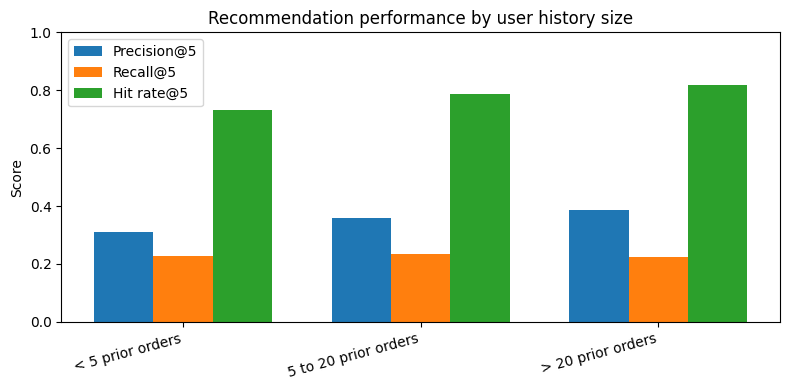

In [24]:
# Bar chart: performance by history group
fig, ax = plt.subplots(figsize=(8, 4))
x = range(len(rq2_df))
width = 0.25
ax.bar([i - width for i in x], rq2_df['precision_at_5'], width, label='Precision@5')
ax.bar(x, rq2_df['recall_at_5'], width, label='Recall@5')
ax.bar([i + width for i in x], rq2_df['hit_rate_at_5'], width, label='Hit rate@5')
ax.set_xticks(x)
ax.set_xticklabels(rq2_df['history_group'], rotation=15, ha='right')
ax.set_ylabel('Score')
ax.set_title('Recommendation performance by user history size')
ax.legend()
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

### Interpretation

- **Users with more order history generally receive better recommendations.** Precision, recall, and hit rate tend to be higher for the "> 20 prior orders" group than for "< 5 prior orders." This matches intuition: the frequency-based recommender has more data to identify recurring purchases for heavy users.

- **Cold start / low-history users perform worse.** Users with fewer than 5 prior orders have less purchase history, so the model has weaker signals to predict their next order. Recommendations may rely on limited product frequency patterns that are noisier.

- **The pattern is consistent across metrics.** If hit rate, precision, and recall all improve with history size, it suggests the effect is robust—it's not just that heavy users get slightly more hits; they get more relevant recommendations overall.

- **Practical implication:** For production systems, consider different strategies for low-history users (e.g., popularity-based fallbacks or onboarding flows) while relying on personalized frequency-based recommendations for users with sufficient history.

# Research Question 3

When comparing products which have been reordered to those that have never been reordered, how is the accuracy of frequency recommendation algorithm when it recommends those products?

Step 1: Build a reorder lookup which contains user_id and product_id from an order and stores reordered value of 1 if the user ordered this product before or 0 if the user has not.

Step 2: Batch recommendation algorithm based on the frequency of a product being ordered by users

Step 3: Create an evaluation function to produce the metrics to split the recommendations into 2 categories: reordered and non-reordered producs

Step 4: Run the recommendation algorithm and get the evaluation metrics to see how accurate the recommendations are for reordered products vs non-reordered products

In [29]:
# Method:
#   - Run the same recommendation algorithm for all users
#   - For each recommended product, look up its reorder value for that user
#   - Split recommendations into two categoeies: reordered vs. never-reordered
#   - Evaluate precision, recall, hit rate separately for each category

import time

# Building a reorder lookup: (user_id, product_id) -> 1 or 0 
# the max() function ensures that if a product ever has reordeed = 1 for a user, it is flagged
reorder_lookup = (
    op_prior
    .groupby(['user_id', 'product_id'])['reordered']
    .max()
    .to_dict()                      # {(user_id, product_id): 0 or 1}
)

# Batch recommender function based on frequency of a product being ordered

def batch_recommend_any(user_ids, k=5):
    df = user_prod_stats[user_prod_stats['user_id'].isin(user_ids)].copy()
    if df.empty:
        return {}
    return (
        df
        .sort_values(
            by=['times_bought', 'last_order_number', 'reorder_rate'],
            ascending=[False, False, False]
        )
        .groupby('user_id')
        .head(k)
        .groupby('user_id')['product_id']
        .apply(list)
        .to_dict()
    )

# Creating Evaluation function that splits recommendations by reorder status

def eval_rq3(user_ids, recs_dict, k=5):
    """
    For each user, split their k recommendations into:
      - reordered bucket : products where reorder_lookup[(uid, pid)] == 1
      - new bucket       : products where reorder_lookup[(uid, pid)] == 0
                           (or product not seen in training orders at all)

    Each bucket is evaluated independently against the full truth set.
    Users who have zero recs in a bucket are excluded from that bucket only.
    """
    metrics = {
        'reordered': {'ps': [], 'rs': [], 'hrs': []},
        'new':       {'ps': [], 'rs': [], 'hrs': []},
    }

    for uid in user_ids:
        if uid not in truth:
            continue

        all_recs  = recs_dict.get(uid, [])
        truth_set = truth[uid]

        # split recs into two buckets based on reorder flag
        reordered_recs = [
            pid for pid in all_recs
            if reorder_lookup.get((uid, pid), 0) == 1
        ]
        new_recs = [
            pid for pid in all_recs
            if reorder_lookup.get((uid, pid), 0) == 0
        ]

        # evaluate each bucket independently (skip if bucket is empty for user)
        for bucket, recs in [('reordered', reordered_recs), ('new', new_recs)]:
            if not recs:
                continue
            metrics[bucket]['ps'].append(precision_at_k(recs, truth_set, len(recs)))
            metrics[bucket]['rs'].append(recall_at_k(recs, truth_set, len(recs)))
            metrics[bucket]['hrs'].append(hit_rate_at_k(recs, truth_set, len(recs)))

    results = []
    for bucket, m in metrics.items():
        n = len(m['ps'])
        results.append({
            'bucket':         bucket,
            'n_users':        n,
            'precision_at_5': round(sum(m['ps']) / n, 4) if n else 0.0,
            'recall_at_5':    round(sum(m['rs']) / n, 4) if n else 0.0,
            'hit_rate_at_5':  round(sum(m['hrs']) / n, 4) if n else 0.0,
        })
    return pd.DataFrame(results)


# Executing functions for Research Question 3

all_user_ids = list(truth.keys())

print("Building recommendations …")
t0 = time.time()
recs_dict = batch_recommend_any(all_user_ids, k=5)
print(f"  Done in {time.time()-t0:.2f}s")

# Sanity check: how are recs distributed across buckets?
total_reordered = sum(
    1 for uid, pids in recs_dict.items()
    for pid in pids if reorder_lookup.get((uid, pid), 0) == 1
)
total_new = sum(
    1 for uid, pids in recs_dict.items()
    for pid in pids if reorder_lookup.get((uid, pid), 0) == 0
)
total_recs = total_reordered + total_new
print(f"\n  Rec breakdown across all users:")
print(f"    Reordered products : {total_reordered:,} ({total_reordered/total_recs*100:.1f}%)")
print(f"    Never-reordered    : {total_new:,} ({total_new/total_recs*100:.1f}%)")

print("\nEvaluating …")
rq3_df = eval_rq3(all_user_ids, recs_dict, k=5)

print("\n── RQ3 Results ──────────────────────────────────────────────────────────")
print(rq3_df.to_string(index=False))
rq3_df

Building recommendations …
  Done in 8.27s

  Rec breakdown across all users:
    Reordered products : 594,952 (91.3%)
    Never-reordered    : 56,708 (8.7%)

Evaluating …

── RQ3 Results ──────────────────────────────────────────────────────────
   bucket  n_users  precision_at_5  recall_at_5  hit_rate_at_5
reordered   129267          0.3758       0.2212         0.7718
      new    22400          0.1274       0.0774         0.2537


,bucket,n_users,precision_at_5,recall_at_5,hit_rate_at_5
0,reordered,129267,0.3758,0.2212,0.7718
1,new,22400,0.1274,0.0774,0.2537


In [30]:
import sys
print(sys.executable)

/Users/raunakkhanna/Desktop/COSC_301_Group_4_Instacart_Basket_Analysis/.venv/bin/python


In [31]:
from tabpy.tabpy_tools.client import Client

client = Client('http://localhost:9004/')

def recommend_frequency_endpoint(user_ids):
    results = []
    for uid in user_ids:
        recs = recommend_top5_frequency(uid)
        results.append(recs['product_id'].tolist() if not recs.empty else [])
    return results

client.deploy(
    'recommend_frequency',
    recommend_frequency_endpoint,
    'Returns top 5 product IDs for a user',
    override=True
)

OSError: [Errno 28] No space left on device

In [ ]:
# Export key tables for Tableau
user_prod_stats.to_csv('../raw_data/user_prod_stats.csv', index=False)
products[['product_id','product_name','aisle_id','department_id']].to_csv('../raw_data/products_clean.csv', index=False)
aisles.to_csv('../raw_data/aisles_clean.csv', index=False)

# Optional: a sample of op_prior (it's large)
op_prior.sample(100000, random_state=42).to_csv('../raw_data/op_prior_sample.csv', index=False)

print("Done!")

Done!


## Tableau Visualization: Top 10 Products by Purchase Frequency

![Top 10 Products by Purchase Frequency](../images/top10_purchase_frequency.png)

## Tableau Visualization: Top 10 Products by Average Reorder Rate

![Top 10 Products by Average Reorder Rate](../images/top10_avg_reorder_rate.png)

## Tableau Visualization: Recommendation Performance By User History Size

![Recommendation Performance By User History Size](../images/sheet3.png)

In [32]:
rq2_df.to_csv("../raw_data/performance_by_history_group.csv", index=False)
rq3_df.to_csv("../raw_data/reordered_vs_new_performance.csv", index=False)

print("saved")

saved
